#Actividad 1

In [ ]:
# imports y carga dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, auc, classification_report)
from sklearn.pipeline import Pipeline

# Cargar
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

  Modelo   mejor parametro  Accuracy  Precision    Recall        F1
0  NoReg  {'C': 1000000.0}  0.921053   0.970149  0.902778  0.935252
1     L2        {'C': 0.1}  0.973684   0.972603  0.986111  0.979310
2     L1          {'C': 1}  0.991228   0.986301  1.000000  0.993103

Modelo: NoReg mejor parametro: {'C': 1000000.0}


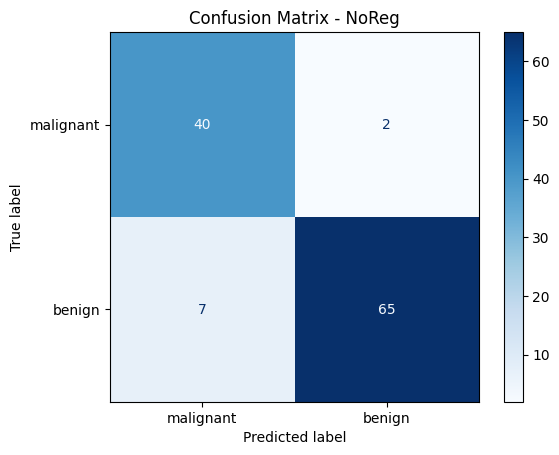


Modelo: L2 mejor parametro: {'C': 0.1}


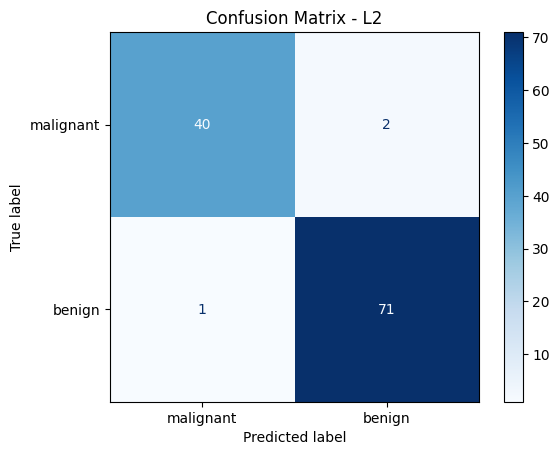


Modelo: L1 mejor parametro: {'C': 1}


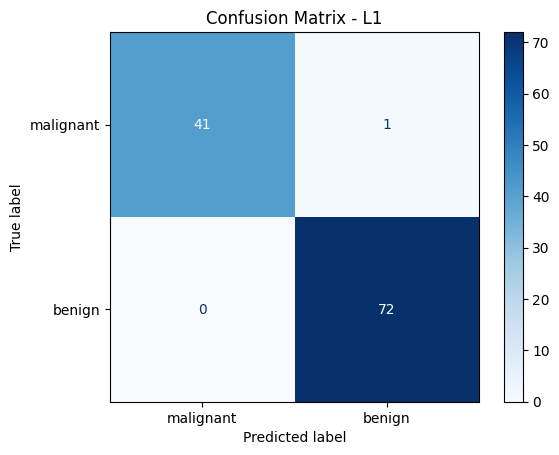

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Train/test 80/20 + estandarizado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Modelos: sin regularización, L2 (Ridge), L1 (Lasso)
models = {
    'NoReg': LogisticRegression(penalty='none', solver='saga', max_iter=10000, random_state=42),
    'L2': LogisticRegression(penalty='l2', solver='lbfgs', max_iter=10000, random_state=42),
    'L1': LogisticRegression(penalty='l1', solver='saga', max_iter=10000, random_state=42)
}

# GridSearch para C en L1 y L2; para NoReg skip gridsearch
param_grid = {'C':[0.01, 0.1, 1, 10, 100]}

best_estimators = {}
results = []

for name, model in models.items():
    if name == 'NoReg':
        # fit directly
        try:
            model.fit(X_train_s, y_train)
            best = model
            best_params = {'C':'none'}
        except Exception as e:
            # fallback to large C if penalty='none' unsupported
            model2 = LogisticRegression(C=1e6, penalty='l2', solver='lbfgs', max_iter=10000, random_state=42)
            model2.fit(X_train_s, y_train)
            best = model2
            best_params = {'C':1e6}
    else:
        grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train_s, y_train)
        best = grid.best_estimator_
        best_params = grid.best_params_
    best_estimators[name] = best

    # Evaluación en test
    y_pred = best.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results.append({'Modelo': name, 'mejor parametro': best_params, 'Accuracy': acc,
                    'Precision': prec, 'Recall': rec, 'F1': f1, 'ConfusionMatrix': cm})

# Mostrar resultados en tabla
df_res = pd.DataFrame(results).drop(columns=['ConfusionMatrix'])
print(df_res)

# Mostrar matrices de confusión
for r in results:
    print("\nModelo:", r['Modelo'], "mejor parametro:", r['mejor parametro'])
    disp = ConfusionMatrixDisplay(confusion_matrix=r['ConfusionMatrix'], display_labels=target_names)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {r['Modelo']}")
    plt.show()


#Actividad 2

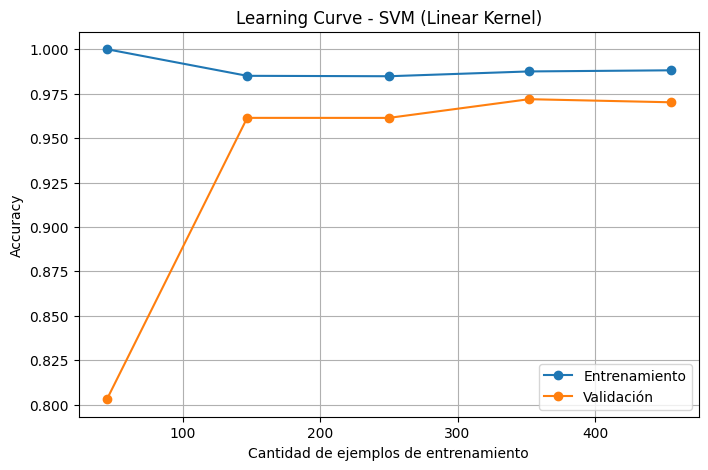

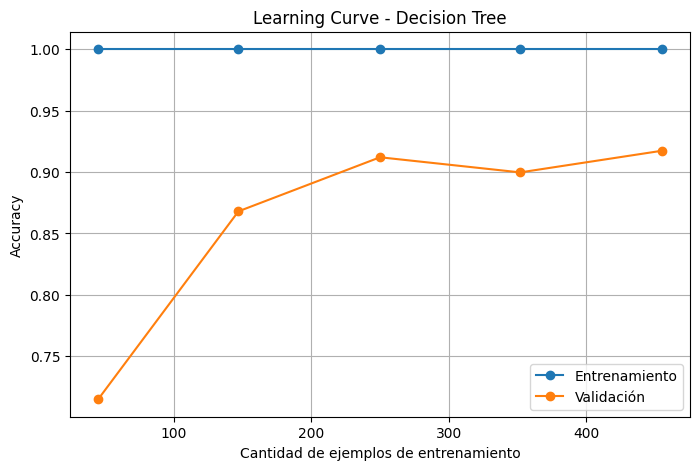

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

#Escalado SOLO para SVM (Decision Tree no lo necesita)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Definición de modelos
svm_model = SVC(kernel="linear", C=1, random_state=42)
tree_model = DecisionTreeClassifier(random_state=42)

# Función para graficar curvas de aprendizaje

def plot_learning_curve(model, X, y, title):
    # train_sizes: distintos tamaños de entrenamiento para evaluar
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,                    # Validación cruzada con 5 folds
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy',
        n_jobs=-1               # Usa todos los núcleos disponibles
    )

    # Promedios de accuracy
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    # GRAFICAR
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, 'o-', label="Entrenamiento")
    plt.plot(train_sizes, val_mean, 'o-', label="Validación")

    plt.title(title)
    plt.xlabel("Cantidad de ejemplos de entrenamiento")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

#Graficar curvas de aprendizaje
plot_learning_curve(svm_model, X_scaled, y, "Learning Curve - SVM (Linear Kernel)")
plot_learning_curve(tree_model, X, y, "Learning Curve - Decision Tree")


#Actividad 3

--- Tabla Comparativa de Métricas (Accuracy y AUC) ---
              Accuracy     AUC
Modelo                        
KNN             0.9649  0.9792
SVM RBF         0.9825  0.9950
RandomForest    0.9561  0.9927
Voting HARD     0.9737  0.9692
Voting SOFT     0.9649  0.9940


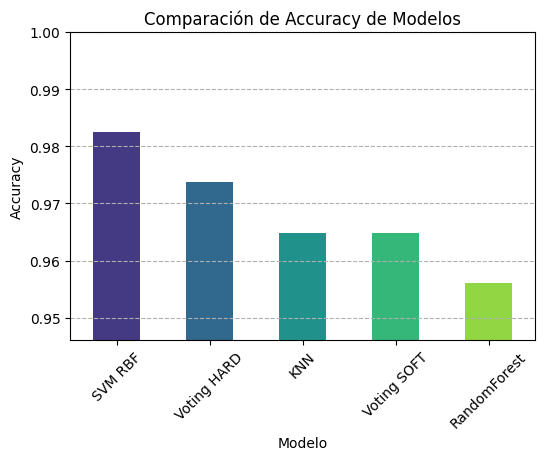

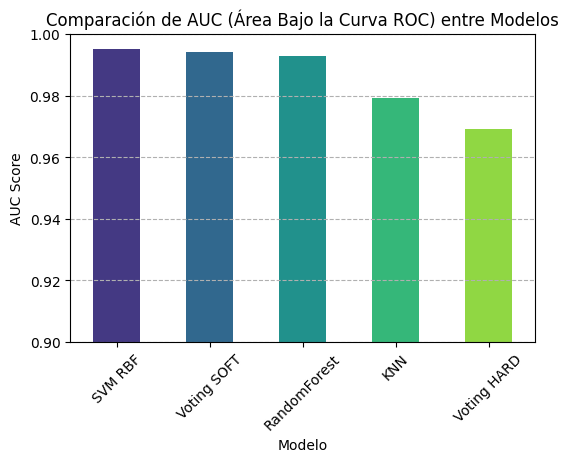


El mejor modelo por Accuracy es: SVM RBF


<Figure size 700x600 with 0 Axes>

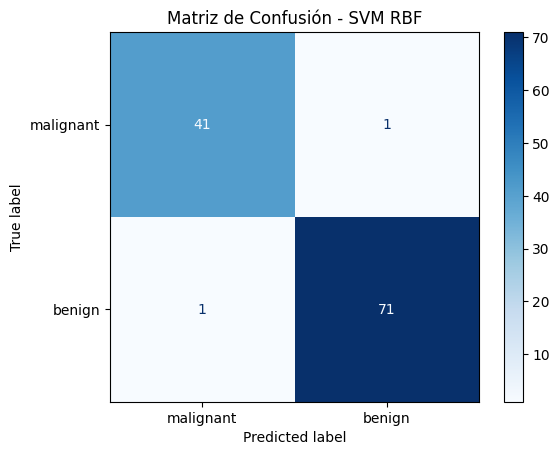

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y )

# Modelos individuales
knn = KNeighborsClassifier(n_neighbors=5)
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
rf = RandomForestClassifier(n_estimators=150, random_state=42)

modelos_base = {
    "KNN": knn,
    "SVM RBF": svm_rbf,
    "RandomForest": rf
}

resultados = []
predicciones_test = {}

# Entrenar y evaluar modelos base
for nombre, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]

    predicciones_test[nombre] = y_pred # Guardar predicción

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

# VotingClassifier
estimators = [("knn", knn), ("svm", svm_rbf), ("rf", rf)]

# Hard Voting
voting_hard = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
voting_hard.fit(X_train, y_train)
pred_hard = voting_hard.predict(X_test)
predicciones_test["Voting HARD"] = pred_hard

# AUC de Hard Voting: Usamos las clases predichas (0 o 1) para el cálculo.
resultados.append({
    "Modelo": "Voting HARD",
    "Accuracy": accuracy_score(y_test, pred_hard),
    "AUC": roc_auc_score(y_test, pred_hard)
})

# Soft Voting
voting_soft = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_soft.fit(X_train, y_train)
pred_soft = voting_soft.predict(X_test)
prob_soft = voting_soft.predict_proba(X_test)[:,1]
predicciones_test["Voting SOFT"] = pred_soft

resultados.append({
    "Modelo": "Voting SOFT",
    "Accuracy": accuracy_score(y_test, pred_soft),
    "AUC": roc_auc_score(y_test, prob_soft)
})

# Tabla comparativa
df_res = pd.DataFrame(resultados).set_index('Modelo')
print("--- Tabla Comparativa de Métricas (Accuracy y AUC) ---")
print(df_res.round(4))

# Gráfico de barras para comparar Accuracy
plt.figure(figsize=(6, 4))
df_res['Accuracy'].sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("viridis", len(df_res)))
plt.title('Comparación de Accuracy de Modelos')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(df_res['Accuracy'].min() - 0.01, 1.0)
plt.grid(axis='y', linestyle='--')
plt.show()

# Gráfico de Comparación de AUC
plt.figure(figsize=(6, 4))
df_res['AUC'].sort_values(ascending=False).plot(kind='bar', color=sns.color_palette("viridis", len(df_res)))
plt.title('Comparación de AUC (Área Bajo la Curva ROC) entre Modelos')
plt.ylabel('AUC Score')
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--')
plt.show()

# Matriz de Confusión del Mejor Modelo
mejor_nombre = df_res['Accuracy'].idxmax()
y_pred_mejor = predicciones_test[mejor_nombre]

print(f"\nEl mejor modelo por Accuracy es: {mejor_nombre}")

cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format='d')
plt.title(f"Matriz de Confusión - {mejor_nombre}")
plt.show()

#Actividad 4


--- Métricas de K-Means ---
   K     Inertia  Silhouette
0  2  11595.6833      0.3447
1  3  10066.2818      0.3152
2  4   9266.1542      0.2742
3  5   9263.4048      0.1645


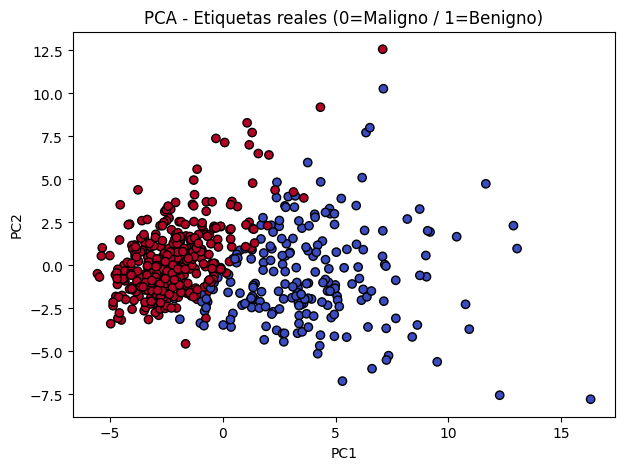

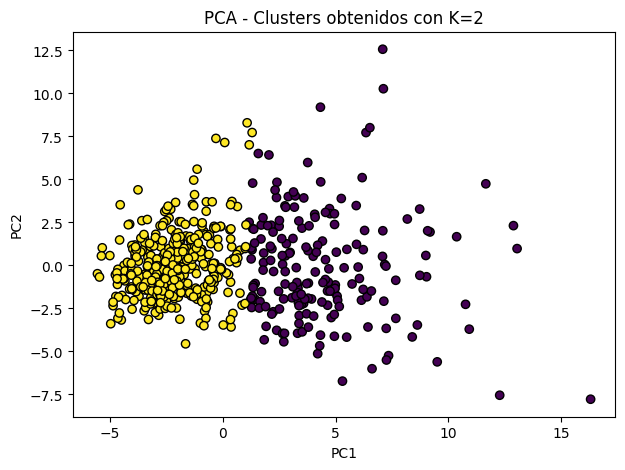

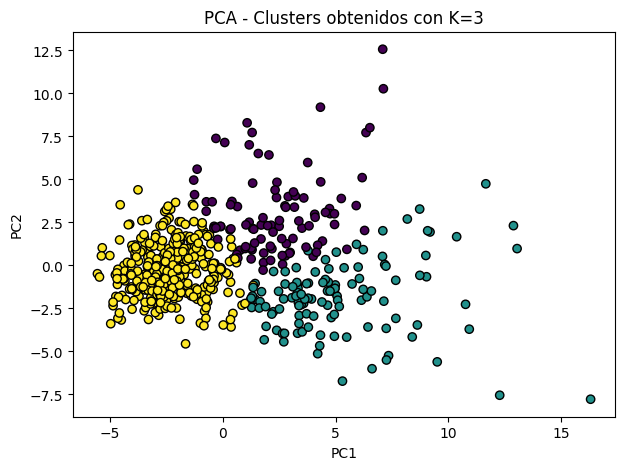

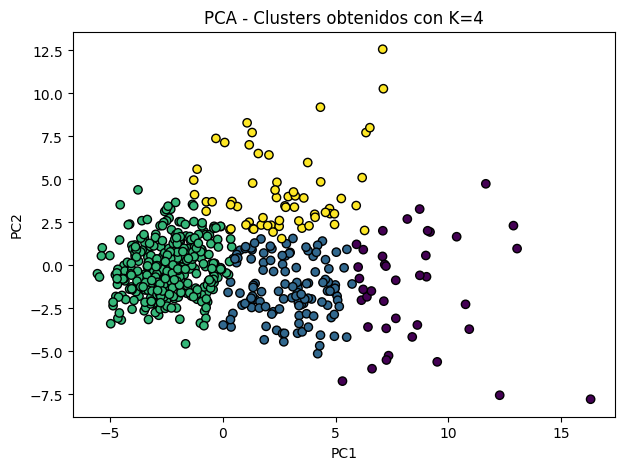

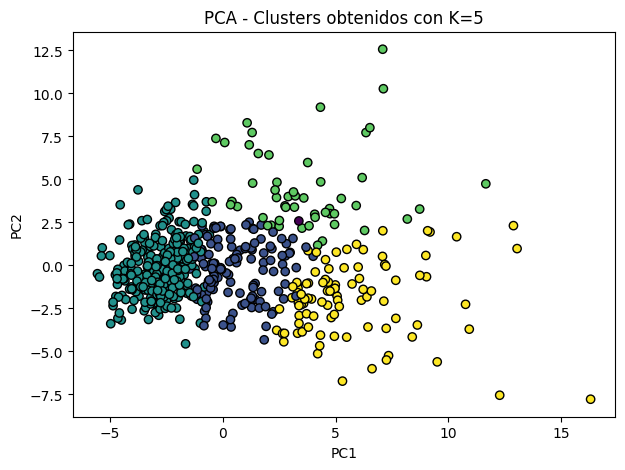

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#K-Means para K = 2,3,4,5
inertias = []
silhouettes = []
models_kmeans = {}

Ks = [2, 3, 4, 5]

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    models_kmeans[k] = km

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Tabla de resultados
df_k = pd.DataFrame({
    "K": Ks,
    "Inertia": inertias,
    "Silhouette": silhouettes
})

print("\n--- Métricas de K-Means ---")
print(df_k.round(4))

#PCA a 2 dimensiones-
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Gráfico: etiquetas reales
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("PCA - Etiquetas reales (0=Maligno / 1=Benigno)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Gráfico para cada K
for k in Ks:
    plt.figure(figsize=(7,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=models_kmeans[k].labels_, cmap='viridis', edgecolor='k')
    plt.title(f"PCA - Clusters obtenidos con K={k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


#Actividad 5

=========== SIN RUIDO ===========
Accuracy SVM: 0.9825
AUC SVM: 0.9950
Accuracy GB: 0.9561
AUC GB: 0.9907


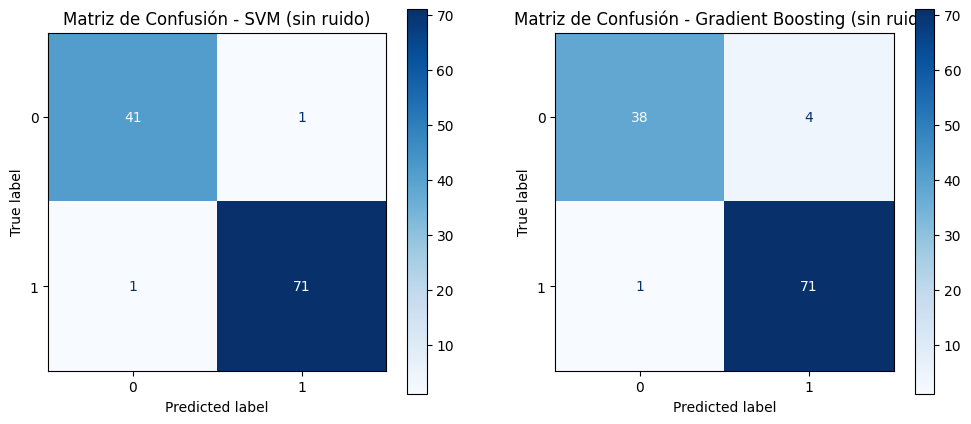


=========== CON 10% RUIDO ===========
Accuracy SVM: 0.9561
AUC SVM: 0.9947
Accuracy GB: 0.9211
AUC GB: 0.9828


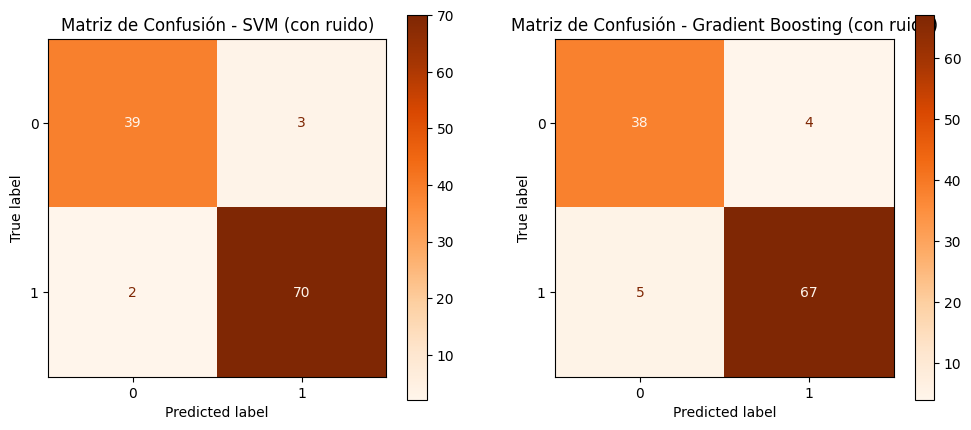

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Modelos
svm = SVC(kernel='rbf', probability=True, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# ENTRENAR SIN RUIDO
svm.fit(X_train, y_train)
gb.fit(X_train, y_train)

pred_svm = svm.predict(X_test)
prob_svm = svm.predict_proba(X_test)[:, 1]

pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, pred_svm)
auc_svm = roc_auc_score(y_test, prob_svm)

acc_gb = accuracy_score(y_test, pred_gb)
auc_gb = roc_auc_score(y_test, prob_gb)

print("=========== SIN RUIDO ===========")
print(f"Accuracy SVM: {acc_svm:.4f}")
print(f"AUC SVM: {auc_svm:.4f}")
print(f"Accuracy GB: {acc_gb:.4f}")
print(f"AUC GB: {auc_gb:.4f}")

#  Matrices de Confusión (sin ruido)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm, ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión - SVM (sin ruido)")

ConfusionMatrixDisplay.from_predictions(y_test, pred_gb, ax=ax[1], cmap="Blues")
ax[1].set_title("Matriz de Confusión - Gradient Boosting (sin ruido)")
plt.show()

# AGREGAR 10% DE RUIDO
np.random.seed(42)
noise_idx = np.random.choice(len(y_train), size=int(0.1 * len(y_train)), replace=False)
y_train_noisy = y_train.copy()
y_train_noisy[noise_idx] = 1 - y_train_noisy[noise_idx]  # flip labels

# RE-ENTRENAR CON RUIDO

svm.fit(X_train, y_train_noisy)
gb.fit(X_train, y_train_noisy)

pred_svm_n = svm.predict(X_test)
prob_svm_n = svm.predict_proba(X_test)[:, 1]

pred_gb_n = gb.predict(X_test)
prob_gb_n = gb.predict_proba(X_test)[:, 1]

acc_svm_n = accuracy_score(y_test, pred_svm_n)
auc_svm_n = roc_auc_score(y_test, prob_svm_n)

acc_gb_n = accuracy_score(y_test, pred_gb_n)
auc_gb_n = roc_auc_score(y_test, prob_gb_n)

print("\n=========== CON 10% RUIDO ===========")
print(f"Accuracy SVM: {acc_svm_n:.4f}")
print(f"AUC SVM: {auc_svm_n:.4f}")
print(f"Accuracy GB: {acc_gb_n:.4f}")
print(f"AUC GB: {auc_gb_n:.4f}")

#  Matrices de Confusión (CON ruido)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm_n, ax=ax[0], cmap="Oranges")
ax[0].set_title("Matriz de Confusión - SVM (con ruido)")

ConfusionMatrixDisplay.from_predictions(y_test, pred_gb_n, ax=ax[1], cmap="Oranges")
ax[1].set_title("Matriz de Confusión - Gradient Boosting (con ruido)")
plt.show()
